# 02. Construcción de la red de residuos y extracción del árbol de expansión mínima

Análisis topológico de la red de comunicación alostérica a partir del árbol de expansión mínima (MST) para el posterior cálculo de centralidad de intermediación a través de la fracción de los caminos más cortos del grafo que atraviesan un nodo específico ("cuellos de botella").

## 1) Inicialización y rutas

In [16]:
import os
import math
import numpy as np
import pandas as pd
import torch
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from Bio.PDB import PDBParser

# Configuración de estilos gráficos de alta resolución para entornos bioinformáticos
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'figure.dpi': 300
})

# Definición de la arquitectura de rutas relativas del proyecto
attention_wt_path = "../data/processed/clean_attention_PKA_Allostery_WT.pt"
attention_mut_path = "../data/processed/clean_attention_PKA_Allostery_I150A.pt"
pdb_path = "../data/processed/PKA_Allostery_scaffold_clean.pdb"

centrality_wt_path = "../results/tables/Centrality_PKA_Allostery_WT.csv"
centrality_mut_path = "../results/tables/Centrality_PKA_Allostery_I150A.csv"

print("Éxito: Entorno operativo y rutas analíticas inicializadas correctamente.")

Éxito: Entorno operativo y rutas analíticas inicializadas correctamente.


## 2) Carga de tensores y PDB

In [17]:
def cargar_y_simetrizar_tensor(ruta_tensor):
    # Tensor filtrado de entrada con dimensiones: (14, 335, 335)
    tensor = torch.load(ruta_tensor, map_location="cpu", weights_only=True)
    consensus = torch.mean(tensor, dim=0).numpy()
    # Simetrización algebraica: el flujo informacional i -> j equivale a j -> i
    matrix_sym = (consensus + consensus.T) / 2.0
    return matrix_sym

matrix_attn_wt = cargar_y_simetrizar_tensor(attention_wt_path)
matrix_attn_mut = cargar_y_simetrizar_tensor(attention_mut_path)
seq_len = matrix_attn_wt.shape[0] # Dimensión estricta del transformador: 335

# Construcción de la máscara geométrica tridimensional del PDB
offset = 14
cutoff_distance = 12.0
parser = PDBParser(QUIET=True)
structure = parser.get_structure("scaffold", pdb_path)
chain = structure[0]["E"]

coords_array = np.full((seq_len, 3), np.nan)
for residue in chain:
    if 'CA' in residue and residue.id[0] == ' ':
        seq_idx = residue.id[1] - 1 - offset
        if 0 <= seq_idx < seq_len:
            coords_array[seq_idx] = residue['CA'].get_coord()

# Cálculo de distancias y conversión en máscara binaria (los NaNs se evalúan como False)
dist_matrix = cdist(coords_array, coords_array, metric='euclidean')
dist_matrix[np.isnan(dist_matrix)] = np.inf
spatial_mask = (dist_matrix <= cutoff_distance).astype(float)

print(f"Éxito: Matrices de atención cargadas ({seq_len}x{seq_len}) y acopladas a la máscara física a {cutoff_distance} Å.")

Éxito: Matrices de atención cargadas (335x335) y acopladas a la máscara física a 12.0 Å.


## 3) $D = -log(P)$ y MST

In [18]:
def extraer_esqueleto_mst(matrix_attn, mask, offset, condicion):
    # Fusión del espacio informacional y geométrico
    physical_matrix = matrix_attn * mask
    G_complete = nx.Graph()

    for i in range(seq_len):
        for j in range(i + 1, seq_len):
            prob = physical_matrix[i, j]
            if prob > 0:
                # Distancia termodinámica invertida de Shannon
                thermo_dist = -math.log(prob)
                # Registro indexado bajo la numeración estructural real del PDB
                G_complete.add_edge(i + 1 + offset, j + 1 + offset, weight=thermo_dist)

    # Extracción del Minimum Spanning Tree (Kruskal)
    G_mst = nx.minimum_spanning_tree(G_complete, weight='weight', algorithm='kruskal')

    # Exportación sistemática de las matrices de adyacencia binarias para el Notebook 03
    nodos_ordenados = sorted(list(G_mst.nodes()))
    adj_matrix = nx.to_numpy_array(G_mst, nodelist=nodos_ordenados)
    np.save(f"../results/networks/undirected_network_PKA_Allostery_{condicion}.npy", adj_matrix)

    print(f"[{condicion}] MST consolidado de forma reproducible. Nodos activos: {G_mst.number_of_nodes()}, Aristas óptimas: {G_mst.number_of_edges()}")
    return G_mst

mst_wt = extraer_esqueleto_mst(matrix_attn_wt, spatial_mask, offset, "WT")
mst_mut = extraer_esqueleto_mst(matrix_attn_mut, spatial_mask, offset, "I150A")

[WT] MST consolidado de forma reproducible. Nodos activos: 333, Aristas óptimas: 332
[I150A] MST consolidado de forma reproducible. Nodos activos: 333, Aristas óptimas: 332


## 4) Visualización de la red 2D

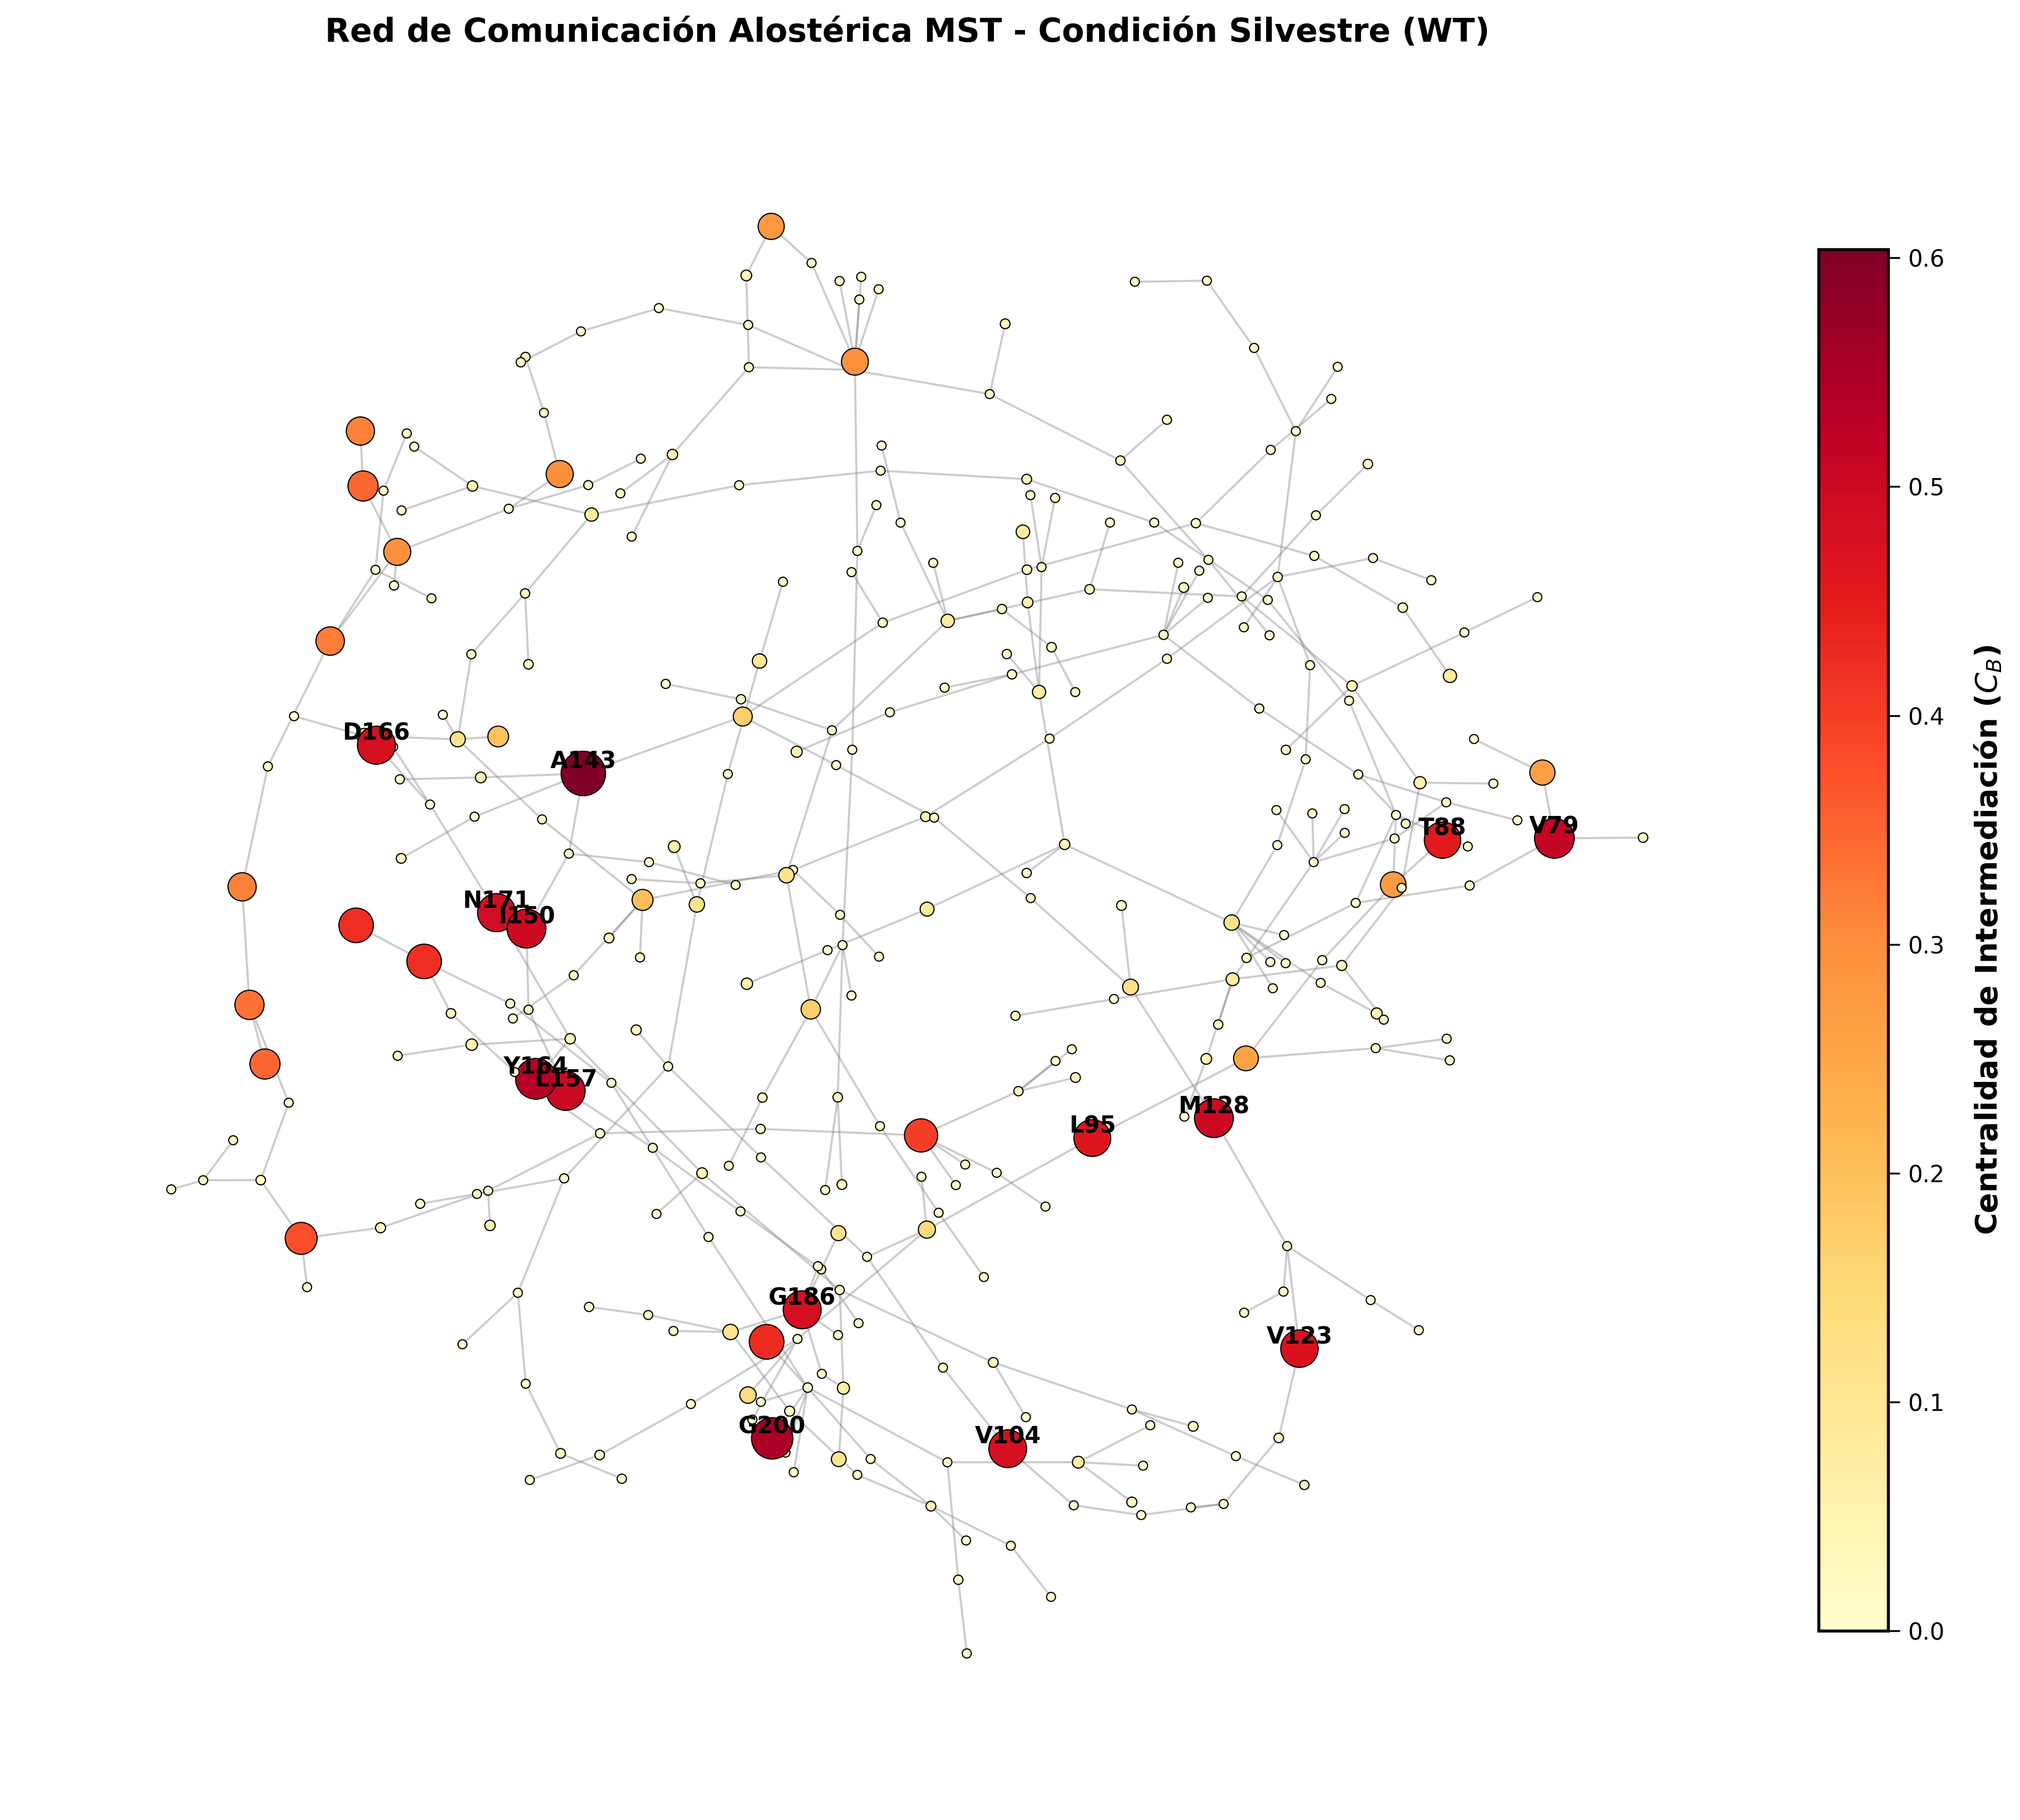

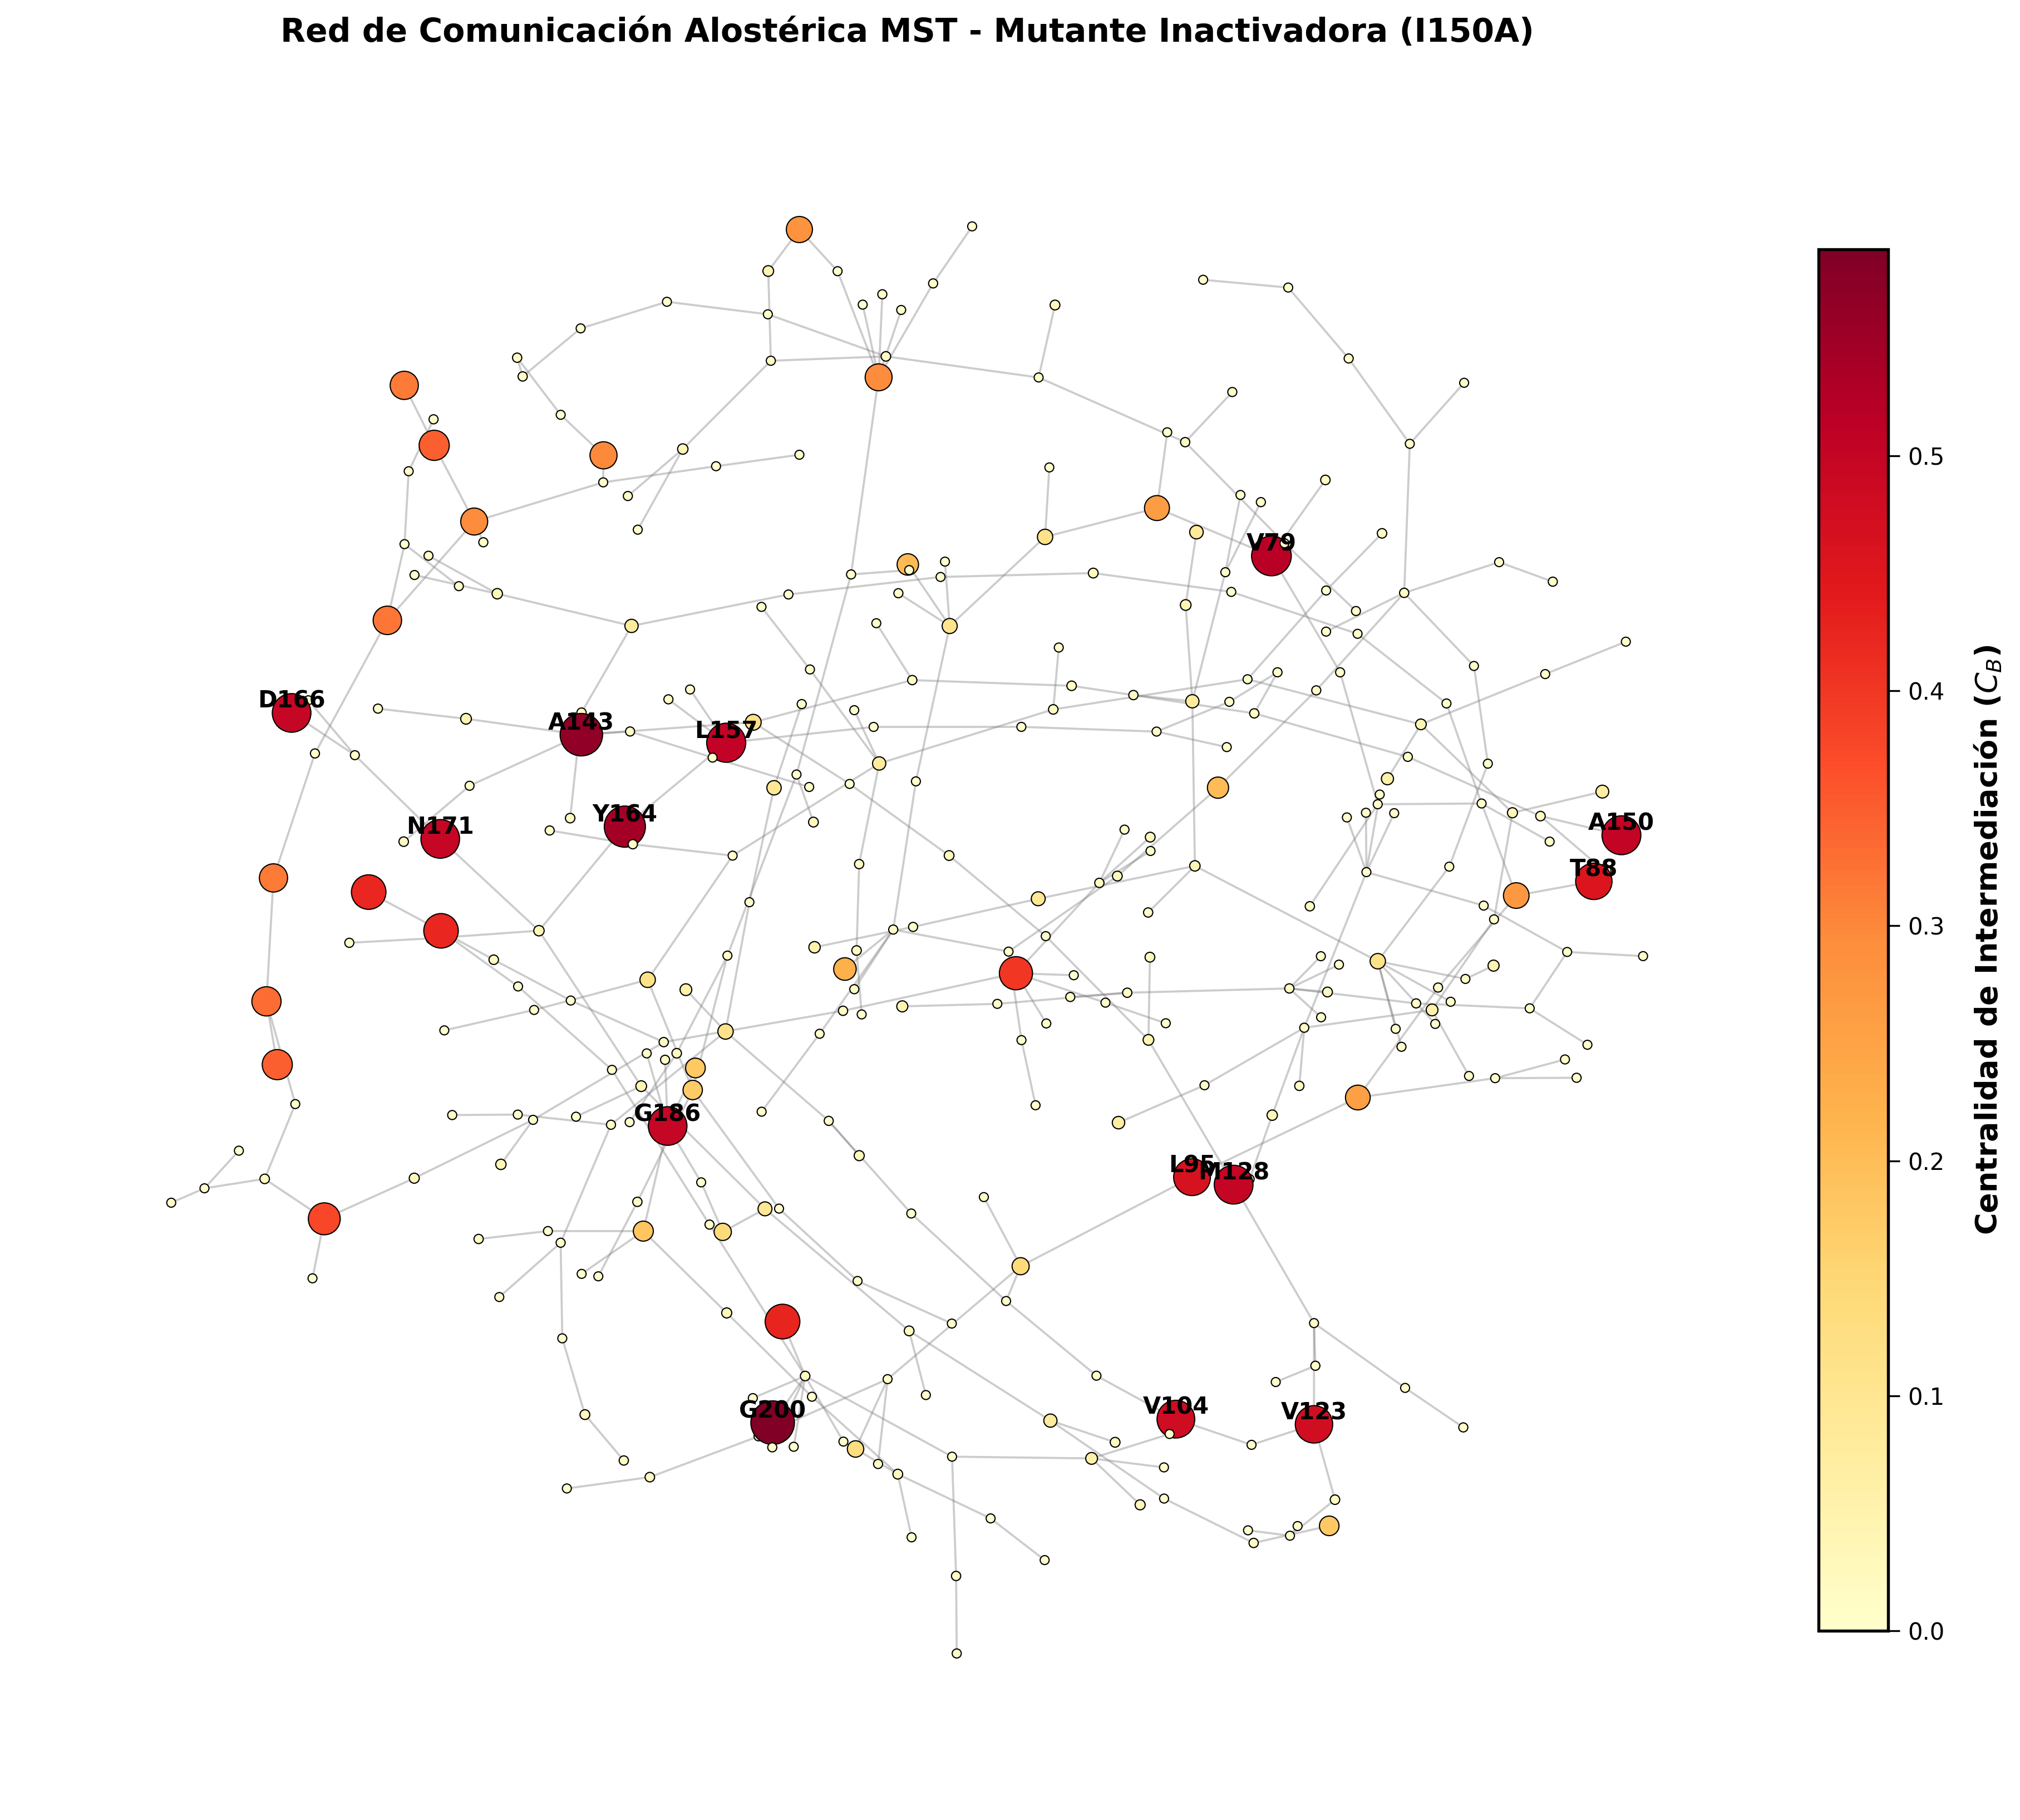

In [19]:
def renderizar_red_alosterica_avanzada(G_mst, ruta_centralidad, titulo_grafica):
    # Carga de perfiles topológicos calculados y mapeo en diccionarios nativos
    df_cent = pd.read_csv(ruta_centralidad)
    dict_centrality = pd.Series(df_cent.Betweenness_Centrality.values, index=df_cent.Residue_PDB).to_dict()
    dict_amino = pd.Series(df_cent.Amino_Acid.values, index=df_cent.Residue_PDB).to_dict()
    dict_bottleneck = pd.Series(df_cent.Is_Bottleneck.values, index=df_cent.Residue_PDB).to_dict()

    # Construcción de vectores vectorizados para el mapeo visual de la topología
    node_list = list(G_mst.nodes())
    node_colors = [dict_centrality.get(n, 0.0) for n in node_list]

    # Escalado proporcional dinámico: tamaño basal mínimo de 15, expandido exponencialmente por su CB
    node_sizes = [15 + 750 * (dict_centrality.get(n, 0.0) ** 1.5) for n in node_list]

    # Generación de etiquetas biológicas combinadas (Aminoácido + Residuo PDB) solo para cuellos de botella
    node_labels = {}
    for n in node_list:
        if dict_bottleneck.get(n, False) and dict_centrality.get(n, 0.0) > 0.45:
            node_labels[n] = f"{dict_amino.get(n, '')}{n}"

    # Inicialización del lienzo gráfico independiente
    fig, ax = plt.subplots(figsize=(13, 11))

    # Layout por fuerzas de muelles optimizado para desenredar ramificaciones arbóreas
    pos = nx.spring_layout(G_mst, k=0.15, iterations=60, seed=7355608)

    # Dibujado geométrico de aristas e interconexiones informacionales
    nx.draw_networkx_edges(G_mst, pos, width=0.9, alpha=0.4, edge_color="gray", ax=ax)

    # Dibujado escalado de los residuos proteicos
    nodes = nx.draw_networkx_nodes(
        G_mst,
        pos,
        nodelist=node_list,
        node_size=node_sizes,
        node_color=node_colors,
        cmap="YlOrRd", # Degradado térmico: desde amarillo (bajo tránsito) hasta rojo oscuro (cuello de botella)
        edgecolors="black",
        linewidths=0.5,
        ax=ax
    )

    # Inyección de las etiquetas de los aminoácidos reguladores críticos
    nx.draw_networkx_labels(
        G_mst,
        pos,
        labels=node_labels,
        font_size=10,
        font_weight="bold",
        font_color="black",
        horizontalalignment="center",
        verticalalignment="bottom"
    )

    # Estilización e inclusión de la barra de escala cuantitativa
    cbar = plt.colorbar(nodes, ax=ax, pad=0.01, shrink=0.8)
    cbar.set_label("Centralidad de Intermediación ($C_B$)", fontsize=13, fontweight="bold", labelpad=12)
    cbar.outline.set_linewidth(1.3)
    cbar.ax.tick_params(labelsize=10)

    ax.set_title(titulo_grafica, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Ejecución paralela e independiente para ambas condiciones experimentales
renderizar_red_alosterica_avanzada(mst_wt, centrality_wt_path, "Red de Comunicación Alostérica MST - Condición Silvestre (WT)")
renderizar_red_alosterica_avanzada(mst_mut, centrality_mut_path, "Red de Comunicación Alostérica MST - Mutante Inactivadora (I150A)")